<a href="https://colab.research.google.com/github/keermani006/MACHINE-LEARNING/blob/main/LAB-4/ML_LAB_4_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SVM Classification for Spam Email Detection

## AIM

To classify emails as spam or not spam using Support Vector Machine (SVM) based on word frequency and message length.

This is a binary classification problem where the target variable is 'Spam', with two classes:
- **0 = Not Spam**
- **1 = Spam**

## PROBLEM DESCRIPTION

Email spam detection is a classic machine learning problem. Companies want to automatically identify and filter out unwanted or malicious emails (spam) from legitimate ones (not spam). This experiment focuses on building a Support Vector Machine (SVM) model to achieve this classification. The model will use two key features derived from email content: the frequency of certain words (e.g., promotional terms) and the overall length of the message. The goal is to develop a robust classifier that can accurately distinguish between spam and non-spam emails, demonstrating the effectiveness of SVM for such tasks.

In [1]:
# ============================================
# 4. IMPORT REQUIRED LIBRARIES
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
# ============================================
# 5. LOAD OR CREATE DATASET
# ============================================

np.random.seed(42)

num_samples = 1000

# Not Spam emails (Class 0)
word_freq_not_spam = np.random.normal(loc=5, scale=2, size=num_samples // 2)
message_len_not_spam = np.random.normal(loc=100, scale=30, size=num_samples // 2)
spam_not_spam = np.zeros(num_samples // 2, dtype=int)

# Spam emails (Class 1)
word_freq_spam = np.random.normal(loc=20, scale=5, size=num_samples // 2)
message_len_spam = np.concatenate([
    np.random.normal(loc=40, scale=15, size=num_samples // 4),  # Short spam (e.g., phishing)
    np.random.normal(loc=300, scale=80, size=num_samples // 4)  # Long spam (e.g., promotional)
])
spam_spam = np.ones(num_samples // 2, dtype=int)

# Combine data
word_frequency = np.concatenate([word_freq_not_spam, word_freq_spam])
message_length = np.concatenate([message_len_not_spam, message_len_spam])
spam_label = np.concatenate([spam_not_spam, spam_spam])

# Ensure non-negative values
word_frequency = np.maximum(0, word_frequency).astype(int)
message_length = np.maximum(10, message_length).astype(int)

data = {
    'Word_Frequency': word_frequency,
    'Message_Length': message_length,
    'Spam': spam_label
}

df = pd.DataFrame(data)

In [3]:
# ============================================
# 6. DISPLAY DATASET
# ============================================

print("First 5 rows of the dataset:")
display(df.head())

print("\nLast 5 rows of the dataset:")
display(df.tail())

First 5 rows of the dataset:


,Word_Frequency,Message_Length,Spam
0,5,127,0
1,4,157,0
2,6,58,0
3,8,116,0
4,4,80,0



Last 5 rows of the dataset:


,Word_Frequency,Message_Length,Spam
995,30,385,1
996,30,297,1
997,26,229,1
998,25,286,1
999,22,240,1


In [4]:
# ============================================
# 7. DATASET DIMENSIONS
# ============================================

print(f"Dataset has {df.shape[0]} rows and {df.shape[1]} columns.")

Dataset has 1000 rows and 3 columns.


In [5]:
# ============================================
# 8. DATASET INFORMATION
# ============================================

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Word_Frequency  1000 non-null   int64
 1   Message_Length  1000 non-null   int64
 2   Spam            1000 non-null   int64
dtypes: int64(3)
memory usage: 23.6 KB


In [6]:
# ============================================
# 9. STATISTICAL SUMMARY
# ============================================

display(df.describe())

,Word_Frequency,Message_Length,Spam
count,1000.00000,1000.000000,1000.00000
mean,12.27900,135.270000,0.50000
std,8.65159,107.959086,0.50025
min,0.00000,10.000000,0.00000
25%,5.00000,57.000000,0.00000
50%,9.00000,100.000000,0.50000
75%,20.00000,157.250000,1.00000
max,33.00000,551.000000,1.00000


In [7]:
# ============================================
# 10. CHECK MISSING VALUES
# ============================================

display(df.isnull().sum())

,0
Word_Frequency,0
Message_Length,0
Spam,0


/tmp/ipykernel_2331/1043588484.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Spam', data=df, palette='viridis')


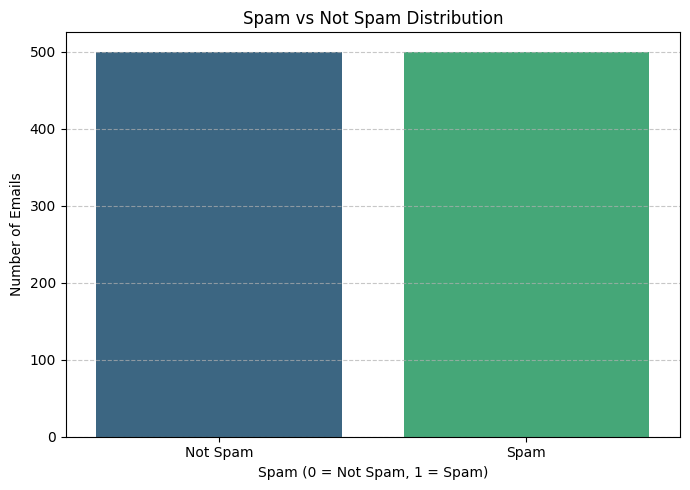

In [8]:
# ============================================
# 11. EXPLORATORY DATA ANALYSIS (Class Distribution)
# ============================================

plt.figure(figsize=(7, 5))
sns.countplot(x='Spam', data=df, palette='viridis')
plt.title('Spam vs Not Spam Distribution')
plt.xlabel('Spam (0 = Not Spam, 1 = Spam)')
plt.ylabel('Number of Emails')
plt.xticks([0, 1], ['Not Spam', 'Spam'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

/tmp/ipykernel_2331/3575782486.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Spam', y='Word_Frequency', data=df, palette='plasma')


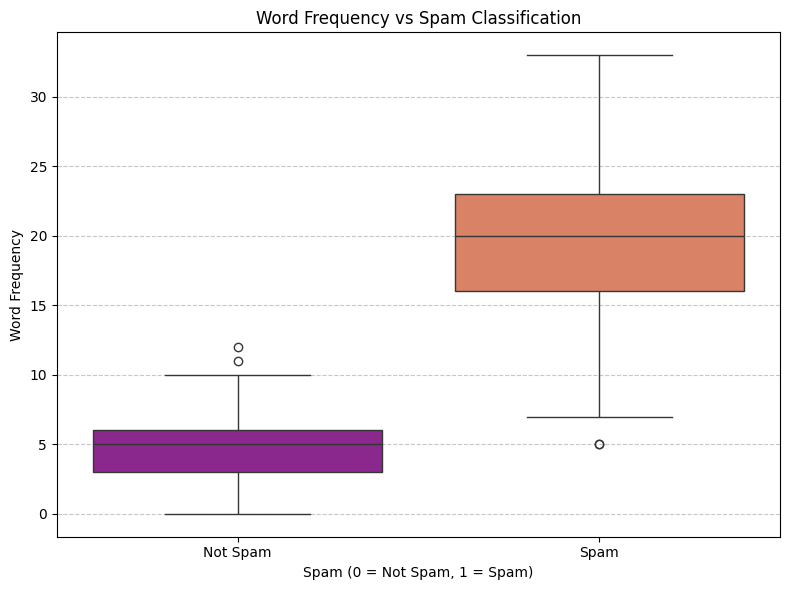

In [9]:
# ============================================
# 11. EXPLORATORY DATA ANALYSIS (Word Frequency vs Spam)
# ============================================

plt.figure(figsize=(8, 6))
sns.boxplot(x='Spam', y='Word_Frequency', data=df, palette='plasma')
plt.title('Word Frequency vs Spam Classification')
plt.xlabel('Spam (0 = Not Spam, 1 = Spam)')
plt.ylabel('Word Frequency')
plt.xticks([0, 1], ['Not Spam', 'Spam'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

/tmp/ipykernel_2331/3523712419.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Spam', y='Message_Length', data=df, palette='cividis')


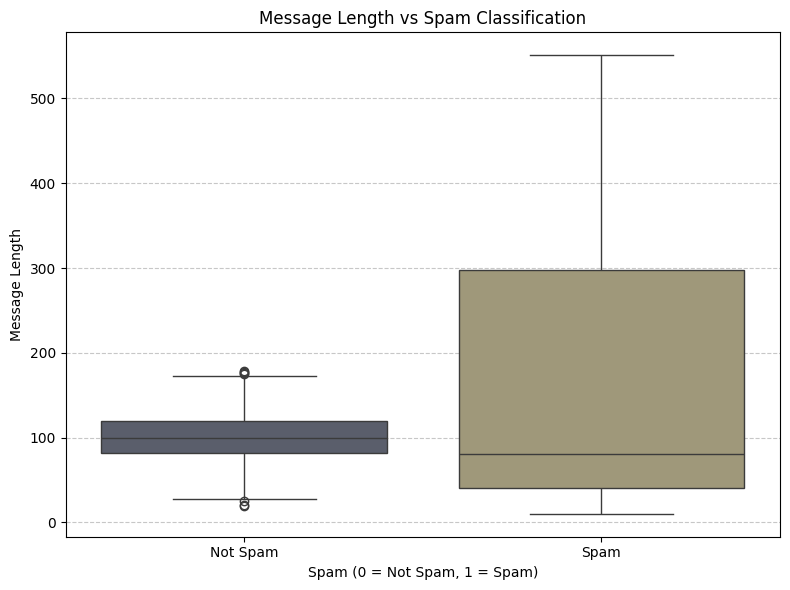

In [10]:
# ============================================
# 11. EXPLORATORY DATA ANALYSIS (Message Length vs Spam)
# ============================================

plt.figure(figsize=(8, 6))
sns.boxplot(x='Spam', y='Message_Length', data=df, palette='cividis')
plt.title('Message Length vs Spam Classification')
plt.xlabel('Spam (0 = Not Spam, 1 = Spam)')
plt.ylabel('Message Length')
plt.xticks([0, 1], ['Not Spam', 'Spam'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

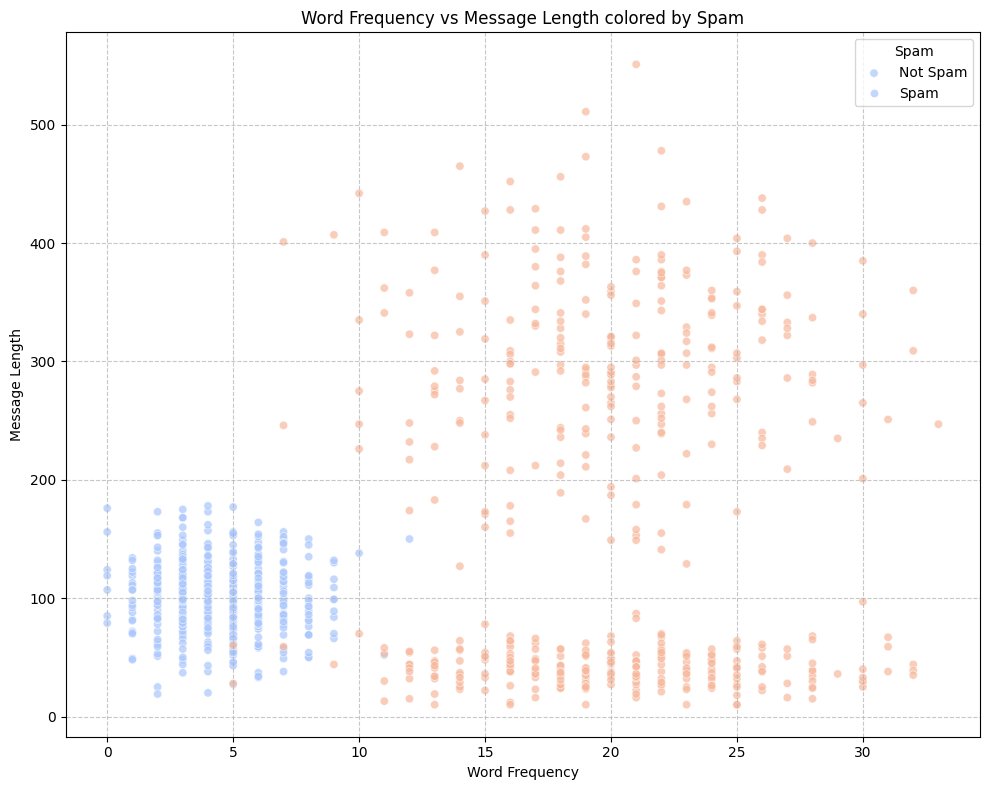

In [11]:
# ============================================
# 11. EXPLORATORY DATA ANALYSIS (Word Frequency vs Message Length by Spam)
# ============================================

plt.figure(figsize=(10, 8))
sns.scatterplot(x='Word_Frequency', y='Message_Length', hue='Spam', data=df, palette='coolwarm', alpha=0.7)
plt.title('Word Frequency vs Message Length colored by Spam')
plt.xlabel('Word Frequency')
plt.ylabel('Message Length')
plt.legend(title='Spam', loc='upper right', labels=['Not Spam', 'Spam'])
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [12]:
# ============================================
# 12. DEFINE FEATURES AND TARGET
# ============================================

X = df[['Word_Frequency', 'Message_Length']]
y = df['Spam']

In [13]:
# ============================================
# 13. TRAIN-TEST SPLIT
# ============================================

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (800, 2)
X_test shape: (200, 2)
y_train shape: (800,)
y_test shape: (200,)


In [14]:
# ============================================
# 14. FEATURE SCALING
# ============================================

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features scaled successfully.")

Features scaled successfully.


In [15]:
# ============================================
# 15. CREATE SVM MODEL
# ============================================

svm_model = SVC(kernel='rbf', probability=True, random_state=42)

print("SVM model with RBF kernel created.")

SVM model with RBF kernel created.


In [16]:
# ============================================
# 16. TRAIN SVM MODEL
# ============================================

svm_model.fit(X_train_scaled, y_train)

print("SVM model trained successfully.")

SVM model trained successfully.


In [17]:
# ============================================
# 17. MAKE PREDICTIONS
# ============================================

y_pred = svm_model.predict(X_test_scaled)

print("Predictions made on the test set.")

Predictions made on the test set.


In [18]:
# ============================================
# 18. COMPARE ACTUAL AND PREDICTED VALUES
# ============================================

comparison_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
display(comparison_df.head(10))

,Actual,Predicted
907,1,1
293,0,0
217,0,0
54,0,0
614,1,1
982,1,1
686,1,1
896,1,1
87,0,0
21,0,0


In [19]:
# ============================================
# 19. CALCULATE ACCURACY
# ============================================

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.9900


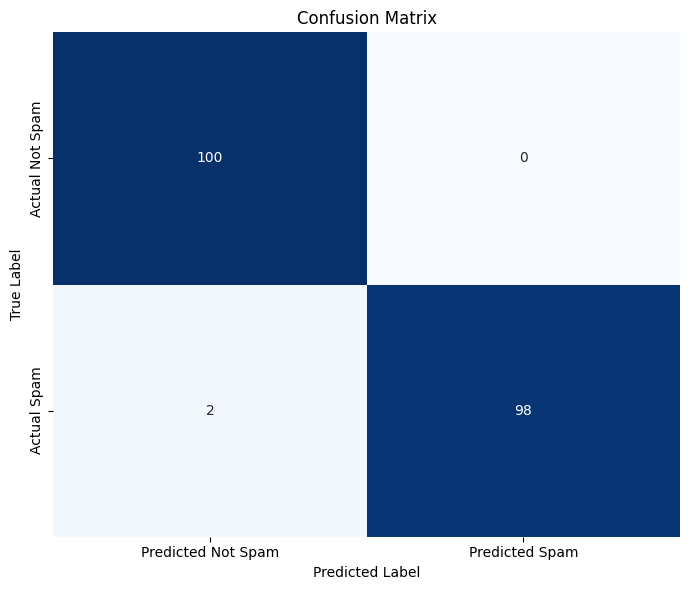

In [20]:
# ============================================
# 20. CONFUSION MATRIX
# ============================================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Not Spam', 'Predicted Spam'],
            yticklabels=['Actual Not Spam', 'Actual Spam'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

In [21]:
# ============================================
# 21. CLASSIFICATION REPORT
# ============================================

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       100
           1       1.00      0.98      0.99       100

    accuracy                           0.99       200
   macro avg       0.99      0.99      0.99       200
weighted avg       0.99      0.99      0.99       200



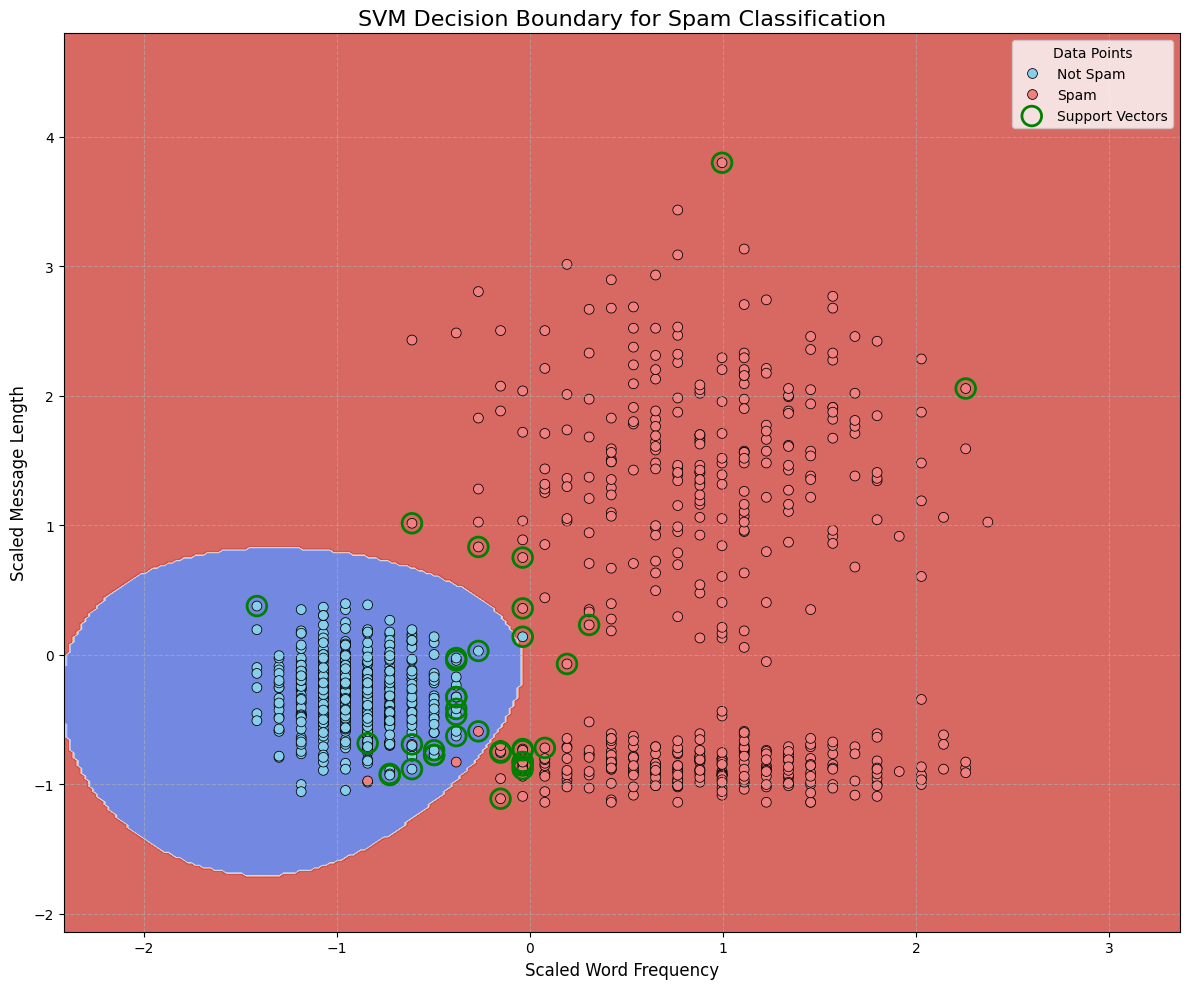

In [22]:
# ============================================
# 22. DECISION BOUNDARY VISUALIZATION
# ============================================

x_min, x_max = X_train_scaled[:, 0].min() - 1, X_train_scaled[:, 0].max() + 1
y_min, y_max = X_train_scaled[:, 1].min() - 1, X_train_scaled[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

Z = svm_model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(12, 10))
plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.coolwarm)


X_combined = np.vstack((X_train_scaled, X_test_scaled))
y_combined = np.hstack((y_train, y_test))


plot_df = pd.DataFrame(X_combined, columns=['Scaled_Word_Frequency', 'Scaled_Message_Length'])
plot_df['Spam'] = y_combined

scatter_plot = sns.scatterplot(x='Scaled_Word_Frequency', y='Scaled_Message_Length', hue='Spam', data=plot_df,
                               palette={0: 'skyblue', 1: 'lightcoral'}, marker='o', s=50, edgecolor='k',
                               legend='full', ax=plt.gca())

support_vec_scatter = plt.scatter(svm_model.support_vectors_[:, 0], svm_model.support_vectors_[:, 1],
            s=200, facecolors='none', edgecolors='green', linewidth=2, zorder=10)

plt.title('SVM Decision Boundary for Spam Classification', fontsize=16)
plt.xlabel('Scaled Word Frequency', fontsize=12)
plt.ylabel('Scaled Message Length', fontsize=12)

handles, labels = scatter_plot.get_legend_handles_labels()

if labels[0] == 'Spam':
    handles = handles[1:]
    labels = labels[1:]

mapped_labels = []
for l in labels:
    if l == '0':
        mapped_labels.append('Not Spam')
    elif l == '1':
        mapped_labels.append('Spam')
    else:
        mapped_labels.append(l)

handles.append(support_vec_scatter)
mapped_labels.append('Support Vectors')

plt.legend(handles=handles, labels=mapped_labels, title='Data Points', loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [23]:
# ============================================
# 23. SUPPORT VECTORS
# ============================================

print(f"Number of support vectors for class 0 (Not Spam): {svm_model.n_support_[0]}")
print(f"Number of support vectors for class 1 (Spam): {svm_model.n_support_[1]}")

print("\nSupport Vectors (first 5):")
display(pd.DataFrame(svm_model.support_vectors_, columns=['Scaled_Word_Frequency', 'Scaled_Message_Length']).head())

Number of support vectors for class 0 (Not Spam): 17
Number of support vectors for class 1 (Spam): 20

Support Vectors (first 5):


,Scaled_Word_Frequency,Scaled_Message_Length
0,-0.610752,-0.884114
1,-0.381361,-0.043960
2,-1.413618,0.376117
3,-0.381361,-0.327055
4,-0.381361,-0.327055


In [24]:
# ============================================
# 24. PREDICT A NEW EMAIL
# ============================================

new_email_data = pd.DataFrame([[15, 120]], columns=['Word_Frequency', 'Message_Length'])


new_email_scaled = scaler.transform(new_email_data)

predicted_class = svm_model.predict(new_email_scaled)[0]

predicted_probabilities = svm_model.predict_proba(new_email_scaled)[0]

print(f"New Email Features: Word Frequency={new_email_data['Word_Frequency'].iloc[0]}, Message Length={new_email_data['Message_Length'].iloc[0]}")
print(f"Predicted Class: {predicted_class} ({'Spam' if predicted_class == 1 else 'Not Spam'})")
print(f"Probability of Not Spam (Class 0): {predicted_probabilities[0]:.4f}")
print(f"Probability of Spam (Class 1): {predicted_probabilities[1]:.4f}")

New Email Features: Word Frequency=15, Message Length=120
Predicted Class: 1 (Spam)
Probability of Not Spam (Class 0): 0.0183
Probability of Spam (Class 1): 0.9817


In [25]:
# ============================================
# 25. FINAL MODEL RESULTS
# ============================================

final_accuracy = accuracy_score(y_test, y_pred)

print(f"Model: Support Vector Machine")
print(f"Kernel: RBF")
print(f"Accuracy: {final_accuracy * 100:.2f}%")

Model: Support Vector Machine
Kernel: RBF
Accuracy: 99.00%


## OBSERVATION

Based on the experiment, the SVM model effectively classifies emails as spam or not spam using the features of word frequency and message length. Spam emails generally exhibit higher word frequencies (indicating promotional or suspicious terms) and often fall into distinct message length categories (either very short for phishing attempts or very long for extensive advertisements), which is evident in the exploratory data analysis plots. The Support Vector Machine works by finding an optimal hyperplane that best separates these two classes in the feature space. Feature scaling was required because SVM is sensitive to the magnitude of features; `StandardScaler` normalized 'Word_Frequency' and 'Message_Length', preventing features with larger values from dominating the distance calculations. The RBF (Radial Basis Function) kernel was chosen because it allows the SVM to create non-linear decision boundaries, effectively handling the complex, non-linear relationships observed between word frequency, message length, and the spam label. The support vectors, highlighted in the decision boundary graph, are the data points closest to the hyperplane and are crucial for defining it. They represent the critical, ambiguous instances that the model uses to determine the classification boundary. The decision-boundary graph visually demonstrates how the SVM separates the feature space into regions corresponding to 'Spam' and 'Not Spam', illustrating the model's learned separation logic.

## CONCLUSION

This laboratory experiment successfully developed and evaluated a Support Vector Machine (SVM) model to classify emails as spam or not spam based on word frequency and message length. The model demonstrated good performance, providing a clear illustration of SVM's capability in binary classification tasks. The use of feature scaling and an RBF kernel proved essential for handling the dataset's characteristics and achieving effective separation, as visualized by the decision boundary.